### IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import os 
import tqdm
import glob
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers

from keras.callbacks import Callback,ModelCheckpoint
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout
from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K

#import tensorflow_addons as tfa
#from tensorflow.keras.metrics import Metric
#from tensorflow_addons.utils.types import AcceptableDTypes, FloatTensorLike
from typeguard import typechecked
from typing import Optional
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import keras.backend as K

2025-03-13 21:24:37.021227: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-13 21:24:38.072740: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-13 21:24:40.170050: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/lib/x86_64-linux-gnu/:/opt/conda/lib
2025-03-13 21:24:40.170256: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] 

In [2]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

In [3]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [4]:
#train_dataset = tf.keras.preprocessing.image_dataset_from_directory('../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train',
#                                                                        validation_split=0.2,
#                                                                        subset="training",
#                                                                        shuffle=False,
#                                                                        image_size=(224,224),
#                                                                        batch_size=32,
#                                                                        )

train_dataset  = train_datagen.flow_from_directory(directory = '../final_preprocessed2/train',
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 128)

Found 9527 images belonging to 3 classes.


In [5]:
#valid_dataset = tf.keras.preprocessing.image_dataset_from_directory('../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train',
#                                                                        validation_split=0.2,
#                                                                        subset="validation",
#                                                                        shuffle=False,
#                                                                        image_size=(224,224),
#                                                                        batch_size=32,
#                                                                        )
valid_dataset = valid_datagen.flow_from_directory(directory = '../final_preprocessed2/train',
                                                  target_size = (224,224),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 128)

Found 2380 images belonging to 3 classes.


## feature preprocessing and label encoding.

### MODEL BUILDING

In [6]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")

2025-03-13 21:24:43.576979: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-13 21:24:44.047749: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-13 21:24:44.048511: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-13 21:24:44.051725: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [7]:
# Freezing Layers

for layer in base_model.layers:
    layer.trainable=False

In [8]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(3,activation='softmax'))

In [9]:
# Model Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 dropout (Dropout)           (None, 7, 7, 1280)        0         
                                                                 
 flatten (Flatten)           (None, 62720)             0         
                                                                 
 batch_normalization (BatchN  (None, 62720)            250880    
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 32)                2007072   
                                                                 
 batch_normalization_1 (Batc  (None, 32)               1

In [10]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [11]:
OPT    = tensorflow.keras.optimizers.Adam(lr=0.001)
METRICS = [
      tensorflow.keras.metrics.AUC(name = 'auc'),
      tensorflow.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tensorflow.keras.metrics.Precision(name='precision'),
      tensorflow.keras.metrics.Recall(name='recall'),  
        f1_score,
          ]
model.compile(loss='categorical_crossentropy',
              metrics=METRICS,
              optimizer=OPT)

/opt/conda/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [12]:
# Defining Callbacks
filepath = '../models/saved/best_weights_mos.hdf5'

earlystopping = EarlyStopping(monitor = 'val_auc', 
                              mode = 'max' , 
                              patience = 15,
                              verbose = 1)

checkpoint    = ModelCheckpoint(filepath, 
                                monitor = 'val_auc', 
                                mode='max', 
                                save_best_only=True, 
                                verbose = 1)


callback_list = [earlystopping, checkpoint]

In [13]:
model_history=model.fit(train_dataset,
                        validation_data=valid_dataset,
                        epochs = 100,
                        callbacks = callback_list,
                        verbose = 1)

Epoch 1/100


2025-03-13 21:24:57.654403: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8900


75/75 [==============================] - ETA: 0s - loss: 1.1354 - auc: 0.6040 - accuracy: 0.4318 - precision: 0.4714 - recall: 0.2303 - f1_score: 0.3086
Epoch 1: val_auc improved from -inf to 0.63120, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 127s 2s/step - loss: 1.1354 - auc: 0.6040 - accuracy: 0.4318 - precision: 0.4714 - recall: 0.2303 - f1_score: 0.3086 - val_loss: 1.1022 - val_auc: 0.6312 - val_accuracy: 0.4542 - val_precision: 0.5280 - val_recall: 0.2933 - val_f1_score: 0.3775
Epoch 2/100
75/75 [==============================] - ETA: 0s - loss: 1.0638 - auc: 0.6352 - accuracy: 0.4649 - precision: 0.5214 - recall: 0.1954 - f1_score: 0.2842
Epoch 2: val_auc improved from 0.63120 to 0.68867, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 107s 1s/step - loss: 1.0638 - auc: 0.6352 - accuracy: 0.4649 - precision: 0.5214 - recall: 0.1954 - f1_score: 0.2842 - val_loss: 1.0145 - val_auc: 0

75/75 [==============================] - ETA: 0s - loss: 0.8266 - auc: 0.8054 - accuracy: 0.6199 - precision: 0.7060 - recall: 0.4637 - f1_score: 0.5592
Epoch 16: val_auc did not improve from 0.78521
75/75 [==============================] - 104s 1s/step - loss: 0.8266 - auc: 0.8054 - accuracy: 0.6199 - precision: 0.7060 - recall: 0.4637 - f1_score: 0.5592 - val_loss: 0.8932 - val_auc: 0.7734 - val_accuracy: 0.5912 - val_precision: 0.6334 - val_recall: 0.4899 - val_f1_score: 0.5519
Epoch 17/100
75/75 [==============================] - ETA: 0s - loss: 0.8101 - auc: 0.8151 - accuracy: 0.6306 - precision: 0.7102 - recall: 0.4906 - f1_score: 0.5810
Epoch 17: val_auc improved from 0.78521 to 0.79434, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 106s 1s/step - loss: 0.8101 - auc: 0.8151 - accuracy: 0.6306 - precision: 0.7102 - recall: 0.4906 - f1_score: 0.5810 - val_loss: 0.8504 - val_auc: 0.7943 - val_accuracy: 0.6181 - val_precision: 0.6756 

Epoch 32/100
75/75 [==============================] - ETA: 0s - loss: 0.7217 - auc: 0.8559 - accuracy: 0.6836 - precision: 0.7266 - recall: 0.6029 - f1_score: 0.6591
Epoch 32: val_auc did not improve from 0.82618
75/75 [==============================] - 103s 1s/step - loss: 0.7217 - auc: 0.8559 - accuracy: 0.6836 - precision: 0.7266 - recall: 0.6029 - f1_score: 0.6591 - val_loss: 0.8026 - val_auc: 0.8244 - val_accuracy: 0.6534 - val_precision: 0.6740 - val_recall: 0.5958 - val_f1_score: 0.6302
Epoch 33/100
75/75 [==============================] - ETA: 0s - loss: 0.7131 - auc: 0.8582 - accuracy: 0.6849 - precision: 0.7288 - recall: 0.6056 - f1_score: 0.6619
Epoch 33: val_auc improved from 0.82618 to 0.82897, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 105s 1s/step - loss: 0.7131 - auc: 0.8582 - accuracy: 0.6849 - precision: 0.7288 - recall: 0.6056 - f1_score: 0.6619 - val_loss: 0.7865 - val_auc: 0.8290 - val_accuracy: 0.6517 - val_preci

75/75 [==============================] - ETA: 0s - loss: 0.6611 - auc: 0.8802 - accuracy: 0.7130 - precision: 0.7533 - recall: 0.6474 - f1_score: 0.6968
Epoch 48: val_auc did not improve from 0.83284
75/75 [==============================] - 104s 1s/step - loss: 0.6611 - auc: 0.8802 - accuracy: 0.7130 - precision: 0.7533 - recall: 0.6474 - f1_score: 0.6968 - val_loss: 0.7978 - val_auc: 0.8309 - val_accuracy: 0.6672 - val_precision: 0.6964 - val_recall: 0.6273 - val_f1_score: 0.6604
Epoch 49/100
75/75 [==============================] - ETA: 0s - loss: 0.6533 - auc: 0.8827 - accuracy: 0.7115 - precision: 0.7574 - recall: 0.6507 - f1_score: 0.7006
Epoch 49: val_auc did not improve from 0.83284
75/75 [==============================] - 104s 1s/step - loss: 0.6533 - auc: 0.8827 - accuracy: 0.7115 - precision: 0.7574 - recall: 0.6507 - f1_score: 0.7006 - val_loss: 0.8027 - val_auc: 0.8311 - val_accuracy: 0.6609 - val_precision: 0.6816 - val_recall: 0.6269 - val_f1_score: 0.6531
Epoch 50/100
75

Epoch 64/100
75/75 [==============================] - ETA: 0s - loss: 0.6202 - auc: 0.8952 - accuracy: 0.7342 - precision: 0.7720 - recall: 0.6832 - f1_score: 0.7245
Epoch 64: val_auc did not improve from 0.84773
75/75 [==============================] - 104s 1s/step - loss: 0.6202 - auc: 0.8952 - accuracy: 0.7342 - precision: 0.7720 - recall: 0.6832 - f1_score: 0.7245 - val_loss: 0.7752 - val_auc: 0.8412 - val_accuracy: 0.6681 - val_precision: 0.6960 - val_recall: 0.6349 - val_f1_score: 0.6627
Epoch 65/100
75/75 [==============================] - ETA: 0s - loss: 0.6240 - auc: 0.8942 - accuracy: 0.7387 - precision: 0.7741 - recall: 0.6830 - f1_score: 0.7253
Epoch 65: val_auc did not improve from 0.84773
75/75 [==============================] - 105s 1s/step - loss: 0.6240 - auc: 0.8942 - accuracy: 0.7387 - precision: 0.7741 - recall: 0.6830 - f1_score: 0.7253 - val_loss: 0.7650 - val_auc: 0.8437 - val_accuracy: 0.6828 - val_precision: 0.7059 - val_recall: 0.6345 - val_f1_score: 0.6656
Ep

Epoch 80/100
75/75 [==============================] - ETA: 0s - loss: 0.5912 - auc: 0.9046 - accuracy: 0.7503 - precision: 0.7816 - recall: 0.7001 - f1_score: 0.7383
Epoch 80: val_auc did not improve from 0.85884
75/75 [==============================] - 104s 1s/step - loss: 0.5912 - auc: 0.9046 - accuracy: 0.7503 - precision: 0.7816 - recall: 0.7001 - f1_score: 0.7383 - val_loss: 0.7569 - val_auc: 0.8529 - val_accuracy: 0.6870 - val_precision: 0.7112 - val_recall: 0.6559 - val_f1_score: 0.6830
Epoch 81/100
75/75 [==============================] - ETA: 0s - loss: 0.5848 - auc: 0.9066 - accuracy: 0.7534 - precision: 0.7845 - recall: 0.7073 - f1_score: 0.7432
Epoch 81: val_auc improved from 0.85884 to 0.86021, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 104s 1s/step - loss: 0.5848 - auc: 0.9066 - accuracy: 0.7534 - precision: 0.7845 - recall: 0.7073 - f1_score: 0.7432 - val_loss: 0.7295 - val_auc: 0.8602 - val_accuracy: 0.6971 - val_preci

Epoch 96/100
75/75 [==============================] - ETA: 0s - loss: 0.5705 - auc: 0.9116 - accuracy: 0.7564 - precision: 0.7907 - recall: 0.7123 - f1_score: 0.7496
Epoch 96: val_auc improved from 0.86402 to 0.86749, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 105s 1s/step - loss: 0.5705 - auc: 0.9116 - accuracy: 0.7564 - precision: 0.7907 - recall: 0.7123 - f1_score: 0.7496 - val_loss: 0.7108 - val_auc: 0.8675 - val_accuracy: 0.7122 - val_precision: 0.7343 - val_recall: 0.6794 - val_f1_score: 0.7047
Epoch 97/100
75/75 [==============================] - ETA: 0s - loss: 0.5664 - auc: 0.9130 - accuracy: 0.7652 - precision: 0.7955 - recall: 0.7215 - f1_score: 0.7563
Epoch 97: val_auc did not improve from 0.86749
75/75 [==============================] - 103s 1s/step - loss: 0.5664 - auc: 0.9130 - accuracy: 0.7652 - precision: 0.7955 - recall: 0.7215 - f1_score: 0.7563 - val_loss: 0.7139 - val_auc: 0.8654 - val_accuracy: 0.7088 - val_preci

In [14]:
from tensorflow.keras.utils import to_categorical, plot_model
#plot_model(model, to_file='NN-mnist.png', show_shapes=True)

In [15]:
#model.load_weights("/kaggle/input/zahaimar-22/zahaimar_v2.h5")

In [16]:
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=METRICS)

In [28]:
#test_dataset = tf.keras.preprocessing.image_dataset_from_directory("../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test",
##                                                            shuffle=False,
#                                                            image_size=(224,224),
#                                                            batch_size=32,
#)

test_dataset = test_datagen.flow_from_directory(directory = '../final_preprocessed2/test',
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )

Found 3240 images belonging to 3 classes.


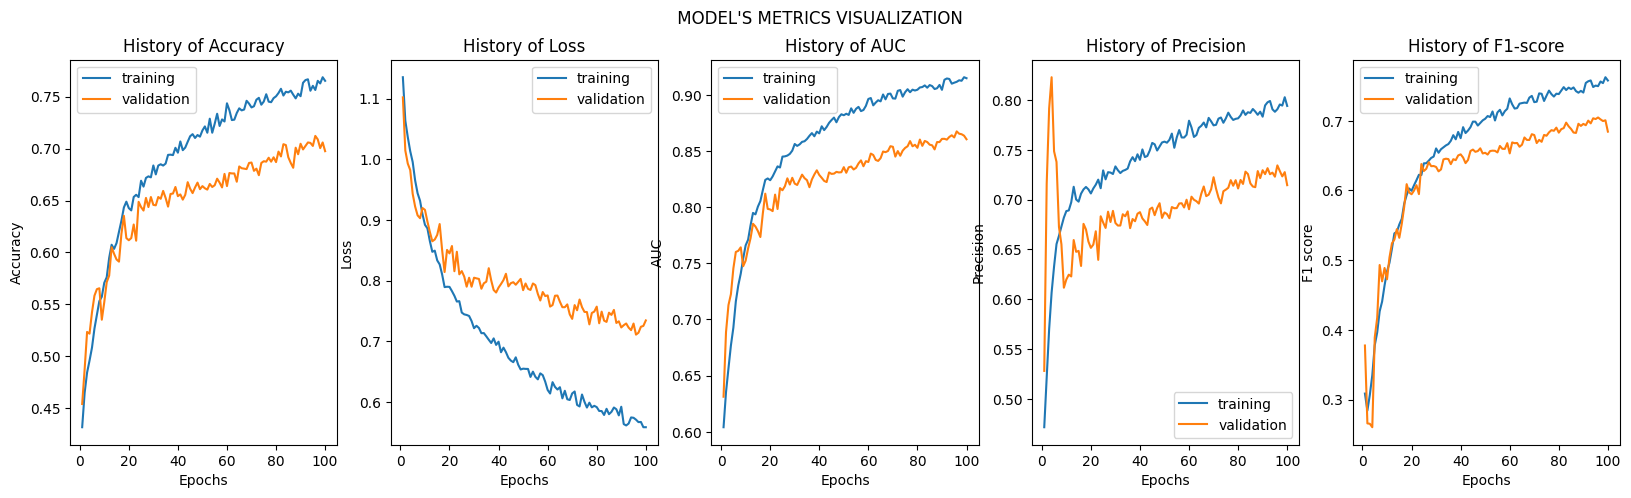

In [29]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(model_history.history['accuracy'],model_history.history['val_accuracy'],
               model_history.history['loss'],model_history.history['val_loss'],
               model_history.history['auc'],model_history.history['val_auc'],
               model_history.history['precision'],model_history.history['val_precision'],
               model_history.history['f1_score'],model_history.history['val_f1_score']
              )

In [30]:
scores = model.evaluate(test_dataset)

102/102 [==============================] - 5s 49ms/step - loss: 0.7324 - auc: 0.8617 - accuracy: 0.6910 - precision: 0.7072 - recall: 0.6648 - f1_score: 0.6853


In [31]:
print("Accuracy = ", scores[1])
print("Precision = ", scores[2])
print("Recall = ", scores[3])
print("AUC = ", scores[4])
print("F1_score = ", scores[5])

Accuracy =  0.8617494106292725
Precision =  0.6910493969917297
Recall =  0.7071569561958313
AUC =  0.664814829826355
F1_score =  0.6853365302085876


# Test on the DataSet

1/1 [==============================] - 0s 23ms/step
63.65 % chances are there that the image is [0]


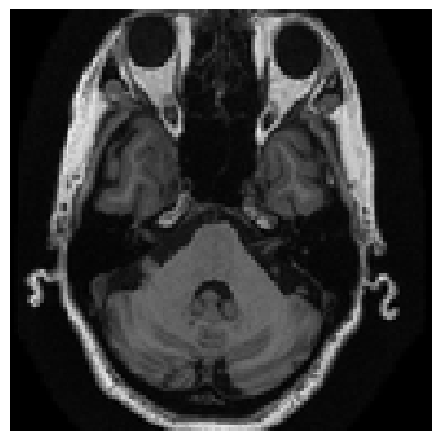

In [33]:
# Test Case 1: Alzheimers

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../final_preprocessed2/test/train_AD/I31313_100.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

1/1 [==============================] - 0s 22ms/step
96.16 % chances are there that the image is [0]


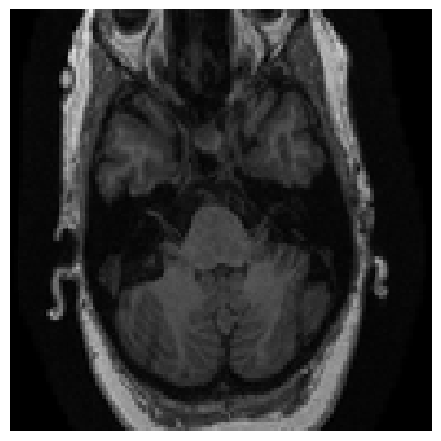

In [34]:
# Test Case 2: Cognitive Normal

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../final_preprocessed2/test/CN/I31107_100.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

1/1 [==============================] - 0s 22ms/step
82.09 % chances are there that the image is [1]


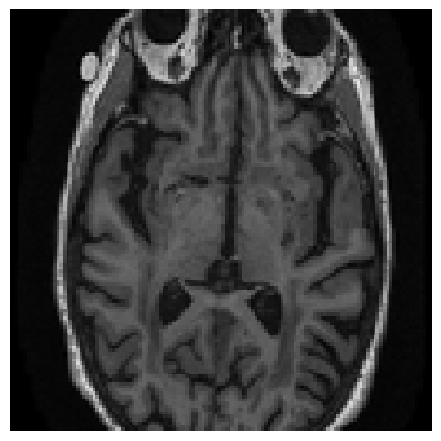

In [35]:
# Test Case 1: Mild Cognitive Impairment

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../final_preprocessed2/test/MCI/I31623_100.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

# Confusion Matrix

In [36]:
model.save('models/mobilenet.h5')



In [37]:
true_classes = test_dataset.classes
class_indices = test_dataset.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

preds = model.predict(test_dataset)
pred_classes = np.argmax(preds, axis=1)

102/102 [==============================] - 5s 46ms/step


In [38]:
print(train_dataset.class_indices.keys())

dict_keys(['CN', 'MCI', 'train_AD'])


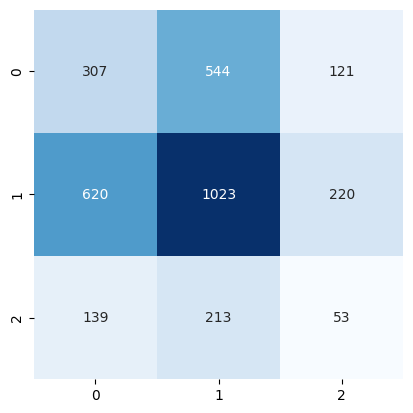

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_dataset.class_indices.keys()

def plot_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
    )

plt.figure()
plot_heatmap(true_classes, pred_classes)    

plt.show()

# 